# Exploration

## Variable cible

In [1]:
import pandas as pd

In [2]:
y = pd.read_csv('../../Dataset/Y_train.csv',index_col=0)
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prdtypecode  84916 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [3]:
if not y.index.is_unique:
    print("Warning: Duplicate indices found!")

In [4]:
y2 = pd.read_csv('../../Dataset/Y_train.csv')
pd.Series(y.index == y2.index).unique(), y2.index

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

L'index de y venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

In [5]:
y2 = pd.read_csv('../../Dataset/Y_train.csv',index_col=0,dtype='str')

In [6]:
y2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  object
dtypes: object(1)
memory usage: 1.3+ MB


In [7]:
y2.nunique()

prdtypecode    27
dtype: int64

In [8]:
y.nunique()

prdtypecode    27
dtype: int64

La variable cible est de type int et n'a pas besoin d'être chargée en type str, car ça n'induit pas ici de doublons. (Un doublon aurait pu par exemple venir d'un code commençant par un zéro dans le CSV, ce zéro disparaissant lors de la conversion en int.)

In [9]:
del y2

Le graphique de Jessy montre en fait tous les codes produits, pas une liste abrégée ! Le préciser dans le rendu.

In [10]:
y.prdtypecode.unique()

array([  10, 2280,   50, 1280, 2705, 2522, 2582, 1560, 1281, 1920, 2403,
       1140, 2583, 1180, 1300, 2462, 1160, 2060,   40,   60, 1320, 1302,
       2220, 2905, 2585, 1940, 1301])

In [11]:
y.head(15)

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
5,2280
6,10
7,2522
8,1280
9,2582


In [12]:
y.describe()

,prdtypecode
count,84916.000000
mean,1773.219900
std,788.179885
min,10.000000
25%,1281.000000
50%,1920.000000
75%,2522.000000
max,2905.000000


In [13]:
y.value_counts()

prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64

In [14]:
v=y.value_counts(normalize=True).tolist()
v

[0.12022469263742994,
 0.05974139149276932,
 0.05941165386970653,
 0.058799283998304204,
 0.05875217862358095,
 0.057350793725564085,
 0.05622026473220595,
 0.05605539592067455,
 0.05067360685854256,
 0.04655188657025767,
 0.03816712986951811,
 0.03669508690941636,
 0.0325144849027274,
 0.031454613971454146,
 0.030488953789627397,
 0.029535069951481464,
 0.029393753827311696,
 0.029334872108907627,
 0.02437703141928494,
 0.0197960337274483,
 0.016734184370436667,
 0.010268971689669792,
 0.009797917942437232,
 0.00970370719299072,
 0.009503509350416883,
 0.009456403975693627,
 0.008997126572141882]

In [15]:
import numpy as np
ratios = [v[k]/v[-1] for k in range(len(v))]
max(ratios),np.median(ratios),np.std(ratios) #,np.mean(ratios)-np.std(ratios),np.mean(ratios)+np.std(ratios)

(13.362565445026178,
 np.float64(3.4960732984293195),
 np.float64(2.7014821668350457))

Comme l'indique le graphique de Jessy, les catégories sont déséquilibrées : la plupart des catégories sont 3 à 13 fois plus représentées que la plus rare. Les rééquilibrer pourrait améliorer la performance.

## Variables d'entrée

In [16]:
X = pd.read_csv('../../Dataset/X_train.csv',index_col=0)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.2+ MB


In [17]:
if not X.index.is_unique:
    print("Warning: Duplicate indices found!")

In [18]:
X2 = pd.read_csv('../../Dataset/X_train.csv')
pd.Series(X.index == X2.index).unique(), X2.index
# L'index de X venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

In [19]:
del X2

In [20]:
X.iloc[:,0].apply(type).unique()

array([<class 'str'>], dtype=object)

In [21]:
X.iloc[:,1].dropna().apply(type).unique()

array([<class 'str'>], dtype=object)

In [22]:
X.head(30)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
5,Afrique Contemporaine N° 212 Hiver 2004 - Doss...,NaN,5862738,393356830
6,Christof E: Bildungsprozessen Auf Der Spur,NaN,91920807,907794536
7,Conquérant Sept Cahier Couverture Polypro 240 ...,CONQUERANT CLASSIQUE Cahier 240 x 320 mm seyès...,344240059,999581347
8,Puzzle Scooby-Doo Avec Poster 2x35 Pieces,NaN,4239126071,1325918866
9,Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - ...,Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m5...,3793572222,1245644185


Les variables imageid et productid semblent inutiles pour la prédiction, et servir juste à associer l'image correspondante lors du preprocessing. Il y a donc essentiellement 3 variables a priori : designation, description, image. Ce petit nombre de variables est une difficulté. En revanche, ces variables semblent avoir un contenu riche et complexe, ce qui offre un potentiel fort si on parvient à les exploiter.

In [23]:
# L'ID est sans doublon, pas de problème.
X.productid.nunique()

84916

In [24]:
# L'ID est sans doublon, pas de problème.
X.imageid.nunique()

84916

### Join

In [25]:
# Join on indexes, according to the documentation of the dataset.
df = X.join(y)
df

,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705
...,...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734,40
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883,2583
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617,2280
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403,1560


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB


### Variables IDs

Les variables productid et imageid sont de type int et n'ont pas besoin d'être chargées en type str, car elles sont déjà sans doublons. (Un doublon aurait pu par exemple venir d'un ID commençant par un zéro dans le CSV, ce zéro disparaissant lors de la conversion en int.)

In [27]:
df.productid.nunique()

84916

In [28]:
df.imageid.nunique()

84916

### Variables textuelles

La variable designation a 3,1% de doublons (2651).

In [29]:
1-X.designation.nunique()/X.shape[0]

0.031219087097837828

In [30]:
X.shape[0] - X.designation.nunique(),X.designation.nunique()

(2651, 82265)

Hormis les NA, la variable description a 13,8% de doublons (7610 sur 55116).

In [31]:
1 - X.description.dropna().nunique() / X.description.dropna().shape[0], X.description.dropna().shape[0] - X.description.dropna().nunique(), X.description.dropna().shape[0], X.description.dropna().nunique()

(0.13807242905871253, 7610, 55116, 47506)

Les textes sont en au moins 3 langues (allemand, français, anglais), ce qui peut compliquer le NLP. Rakuten étant une entreprise mondiale, on peut s'attendre à ce que bien plus que 3 langues soient représentées dans le jeu de données. Mais le français semble majoritaire.

In [32]:
print('\n#\n'.join(X.designation.iloc[:100]))

Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design
#
Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris - Jacques Barrere - Francois Perrier - La Reforme Des Ventes Aux Encheres Publiques - Le Sna Fete Ses Cent Ans.
#
Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style
#
Peluche Donald - Europe - Disneyland 2000 (Marionnette À Doigt)
#
La Guerre Des Tuques
#
Afrique Contemporaine N° 212 Hiver 2004 - Dossier Japon / Afrique
#
Christof E: Bildungsprozessen Auf Der Spur
#
Conquérant Sept Cahier Couverture Polypro 240 X 320 Mm 96 Pages 90g Seyès Incolore
#
Puzzle Scooby-Doo Avec Poster 2x35 Pieces
#
Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - Longueur : 4m50 Largeur : 3 M Blanc H
#
Eames Inspired Sxw Chair - Pink - Black
#
Fauteuil Chesterfield Brenton 100% Cuir De Buffle - Vert Empire
#
Peaceable Kingdom Wheres Bear? The Hide And Find Stacking Block Game For 2 Year Olds
#
Paire De 

Beaucoup d'éléments dans les désignations ne sont pas des mots mais peuvent être quand même pertinents pour la prédiction. Nettoyer les désignations sans nuire à la qualité des prédictions peut être délicat. De nombreuses désignations semblent confuses, difficiles à catégoriser même par un humain.

In [33]:
print('\n#\n'.join(X.dropna().description.iloc[:15]))

PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<br> Pour un confort optimal et une précision maximale sur le GamePad de la Wii U: ce grand stylet hautement ergonomique est non seulement parfaitement adapté à votre main mais aussi très élégant.<br> Il est livré avec un support qui se fixe sans adhésif à l'arrière du GamePad<br> <br> Caractéristiques:<br> Modèle: Speedlink PILOT STYLE Touch Pen<br> Couleur: Bleu<br> Ref. Fabricant: SL-3468-BE<br> Compatibilité: GamePad Nintendo Wii U<br> Forme particulièrement ergonomique excellente tenue en main<br> Pointe à revêtement longue durée conçue pour ne pas abîmer l'écran tactile<br> En bonus : Support inclu pour GamePad<br> <span class="vga_style2"><b></b><br>
#
Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'arranger pour en &ecirc;tre le vainqueur incontest&eacute;. Mais Sophie s'en m&ecirc;le et chambarde tous ses plans...
#
CONQUERANT CLASSIQUE 

Les descriptions aussi sont confuses et parsemées de parasites variés. Leurs tailles sont très variables. L'absence de description pour 35% des données représente aussi une difficulté.

In [34]:
df['len_designation']=X.designation.apply(len)

In [35]:
# Les descriptions non NA sont toutes différentes de la chaîne vide '', donc on n'introduit pas d'ambiguïté avec fillna('').
df['len_description']=X.description.fillna('').apply(len)

In [36]:
#TODO? histogram
# Designation lengths (character counts)
df['len_designation'].describe()

count    84916.000000
mean        70.163303
std         36.793383
min         11.000000
25%         43.000000
50%         64.000000
75%         90.000000
max        250.000000
Name: len_designation, dtype: float64

In [37]:
#TODO? histogram
# description lengths (character counts) (*except* for missing descriptions)
X.description.dropna().apply(len).describe()

count    55116.000000
mean       808.171692
std        805.462153
min          1.000000
25%        259.000000
50%        626.000000
75%       1034.000000
max      12451.000000
Name: description, dtype: float64

In [38]:
#TODO? histogram
# description lengths (character counts) (*including* missing descriptions)
df['len_description'].describe()

count    84916.000000
mean       524.555926
std        754.893905
min          0.000000
25%          0.000000
50%        231.000000
75%        823.000000
max      12451.000000
Name: len_description, dtype: float64

In [39]:
#TODO? values and plot: moyenne de la longueur de la description par type de produit

70 descriptions font moins de 5 caractères et semblent presque toutes inutiles à la prédiction. Heureusement, elles ne représentent que 0,1% du jeu de données.

In [40]:
# Taille, Nombre de descriptions de cette taille
v=X.description.dropna().apply(len)[X.description.dropna().apply(len) <= 5].value_counts().sort_index()
v

description
1    28
2     9
3    14
4    19
5     7
Name: count, dtype: int64

In [41]:
# Descriptions de moins de 5 caractères
X.description.dropna()[X.description.dropna().apply(len) <= 5].unique()

array(['50PV.', '1989', '...', 'promo', '-', '0', '1985', '1984', 'nc',
       '.', 'Batty', '(1', 'p', 'jeu', '1972.', '&gt;', '1980', 'Buste',
       'Noir', '1969', 'aa', 'Gris', 'B1962', '3323', '1988', '1947',
       '1986', '1991', '1992', '--', '1996', 'table'], dtype=object)

In [42]:
# Nombre et pourcentage de ces descriptions
v.sum(),v.sum()/X.description.dropna().shape[0]

(np.int64(77), np.float64(0.0013970534871906525))

À partir de 6 caractères, les descriptions commencent à sembler utiles à la prédiction : par exemple, "Roman", "Chevet", "Proust".

In [43]:
# Descriptions de 6 caractères
X.description.dropna()[X.description.dropna().apply(len) == 6].unique()

array(['<br />', 'doudou', 'Notice', 'Roman.', 'argent', 'F.215.',
       'Proust', 'Marron', '18X7cm', 'Chevet'], dtype=object)

In [44]:
# Descriptions de 7 caractères
X.description.dropna()[X.description.dropna().apply(len) == 7].unique()

array(['Piano -', '34x29cm', '2259.00', 'Mensuel', '...<br>', 'Commode',
       'RoHS CE', 'Poupon '], dtype=object)

#### Mots les plus fréquents

##### Variable : description

In [45]:
text = ' '.join(X.description.dropna().str.lower())
text[:100]

'pilot style touch pen de marque speedlink est 1 stylet ergonomique pour gamepad nintendo wii u.<br> '

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

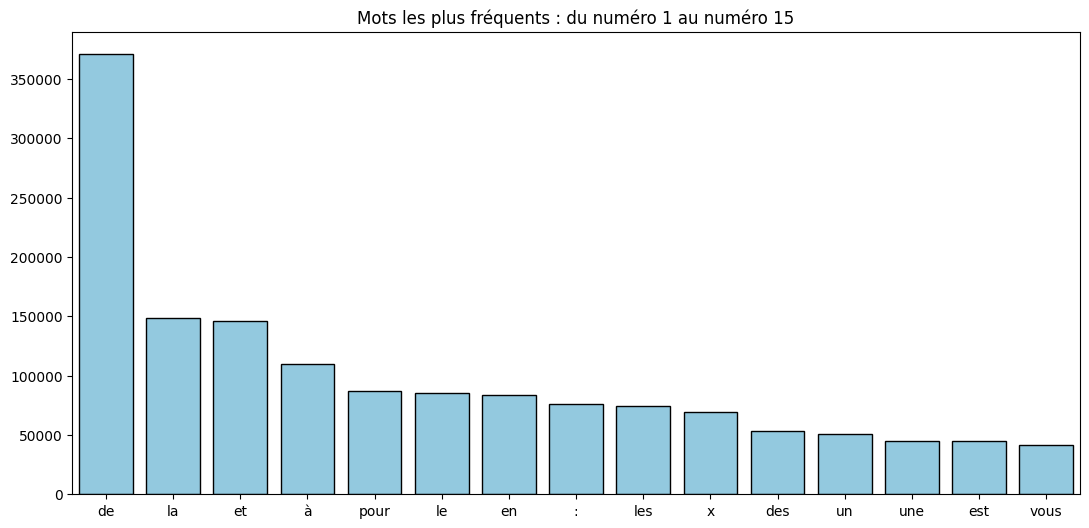

In [46]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [47]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | la | et | à | pour | le | en | : | les | x | des | un | une | est | vous | avec | du | - | /> | votre | 1 | / | <br | dans | ou | sur | pas | cm | plus | peut | il | que | au | ne | haute | par | couleur | a | piscine | être | 2 | * | ce | sont | qualité | qui | the | tout | facile | taille'

In [48]:
# Initialiser la variable des mots vides
stop_words = set('p br li ul cm mm X A b H div'.split())
stop_words |= set(mots)
print(stop_words)

{'ul', 'sur', 'sont', 'taille', '2', 'cm', 'A', 'au', 'avec', 'piscine', '-', 'couleur', 'en', 'du', ':', 'être', 'des', 'the', '*', 'ce', 'et', 'de', 'br', 'mm', '/>', 'ou', 'X', 'ne', 'une', '1', 'pas', 'plus', 'haute', 'x', 'la', 'il', 'vous', 'par', 'facile', 'pour', 'le', 'p', 'div', 'H', 'que', 'a', 'li', 'un', 'les', 'est', 'dans', 'à', 'tout', '/', '<br', 'peut', 'qualité', 'b', 'qui', 'votre'}


In [49]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'and | /><br | taille: | sans | 3 | plaît | matériel: | dimensions | aux | se | comme | 4 | vos | s&#39;il | enfants | 100% | acier | très | bois | &#43; | l&#39;eau | lumière | cette | to | raison | son | produit | />- | neuf | of | décoration | forfait | non | caractéristiques: | temps | jeu | taie | protection | mode | couleur: | d&#39;un | mesure | batterie | d&#39;une | pouvez | type | main | coussin | (l | 6 | mm | tous | 5 | filtration | l | sac | led | &amp; | sa | bébé | comprend: | contenu | avant | d&#39;eau | design | utiliser | for | pompe | maison | ans | plastique | 1x | hauteur | permettre | couleurs | différence | si | 10 | marque | 1pc | nous | fait | rc | paquet | parfait | elle | surface | durable | ! | blanc | ? | poids | //// | style | m? | forme | d&#39;oreiller | peuvent | cadeau | grande | :</strong> | ces | tissu | couverture | permet | sécurité | également | structure | faire | grand | grâce | facilement | longueur | 8 | voiture | utilisé | </p> | système | m

##### Variable : designation

In [50]:
text = ' '.join(X.designation.str.lower())
text[:100]

'olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design journal des'

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

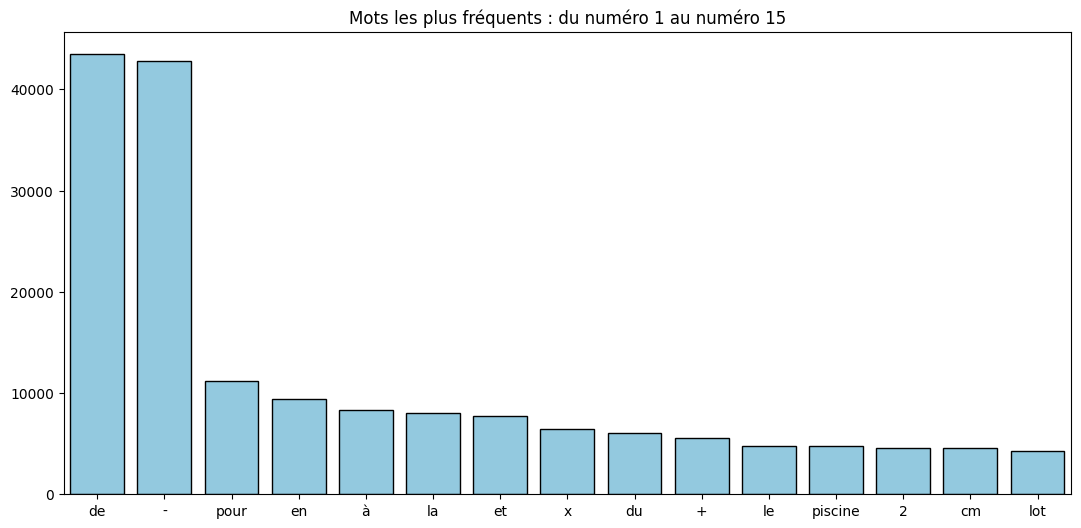

In [51]:
from collections import Counter
import seaborn as sns

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [52]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | - | pour | en | à | la | et | x | du | + | le | piscine | 2 | cm | lot | n° | les | jeu | avec | coussin | : | des | 3 | / | 1 | m | kit | 4 | rc | taie | enfants | blanc | a | bois | led | the | décor | noël | home | & | bébé | décoration | sac | noir | jeux | bâche | bleu | drone | 5 | par'

In [53]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'of | carte | mini | 6 | couverture | journal | portable | d\'oreiller | dji | acier | jouet | sur | console | mm | lampe | au | cadeau | magideal | voiture | cuisine | 10 | jardin | set | jouets | gris | spa | table | canapé | figurine | housse | pompe | carnet | coton | tapis | toy | classique | bulles | bricolage | tissu | for | support | case | ronde | rouge | maison | douche | téléchargement | 8 | peinture | vert | protection | cover | notes | intex | collection | un | 3d | 12 | super | rose | filtre | livres | quadcopter | peluche | 7 | bain | couleur | salle | bloc-notes | l | lit | stream | gonflable | oreiller | car | sans | pièces | modèle | nintendo | cahier | lumière | solaire | enfant | matelas | sofa | pro | bureau | métal | taille | edition | accueil | france | caméra | throw | papier | plastique | and | silicone | poche | rangement | 20 | pouces | pvc | accessoires | double | mode | fpv | places | tome | (le) | batterie | mavic | star | decor | magic | chaise | | | dans

#### Wordclouds

##### Initialisation

In [54]:
# Complète l'installation de nltk. Utile seulement une fois par PC.
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/val/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
from nltk.corpus import stopwords

stop_words |= set(stopwords.words('french'))
print(stop_words)

{'ces', 'fussions', 'sont', 'aura', 'été', 'ayantes', '2', 'serons', 'auriez', 'aient', 'A', 'au', 'étants', 'eussiez', 'ton', 'lui', 'soit', 'du', 'auront', 'serions', 'aies', 'br', 'ou', 'X', 'serais', 'ne', 'sois', '1', 'm', 'nos', 'eussent', 'haute', 'même', 'eût', 'elle', 'x', 'la', 'il', 'seras', 'étions', 'eues', 'mes', 'nous', 'fûtes', 'le', 'n', 'que', 'c', 'li', 'leur', 'les', '/', 'qualité', '<br', 'peut', 'eus', 'est', 'b', 'qui', 'eu', 'fûmes', 'd', 'sur', 'sa', 'se', 'eûtes', 'ils', 'soyons', 'piscine', 'es', 'étiez', 'étant', 'étante', 'en', 'ce', 'seraient', 'soyez', 'aurons', 'avait', '/>', 'serai', 'eurent', 'on', 'furent', 'mais', 'plus', 'eûmes', 't', 'ma', 'vous', 'par', 'facile', 'auras', 'étée', 'vos', 'eut', 'div', 'avions', 'y', 'fusses', 'à', 'ai', 'j', 'votre', 'qu', 'me', 's', 'ul', 'étés', 'était', 'fussiez', 'toi', 'étais', 'eusses', 'eux', 'eue', 'êtes', '-', 'couleur', 'aie', 'soient', ':', 'être', 'seront', 'des', 'the', '*', 'ont', 'et', 'mm', 'aux', '

In [56]:
# Mieux sans masque
mask_coloring = None

In [57]:
# from PIL import Image
# path = 'images/mask.png'
# mask_coloring = np.array(Image.open(str(path)))

##### Variable : designation

In [58]:
import wordcloud
from wordcloud import WordCloud
wc1 = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [59]:
text = ' '.join(X.designation)
wc1.generate(text)
len(text)

6042902

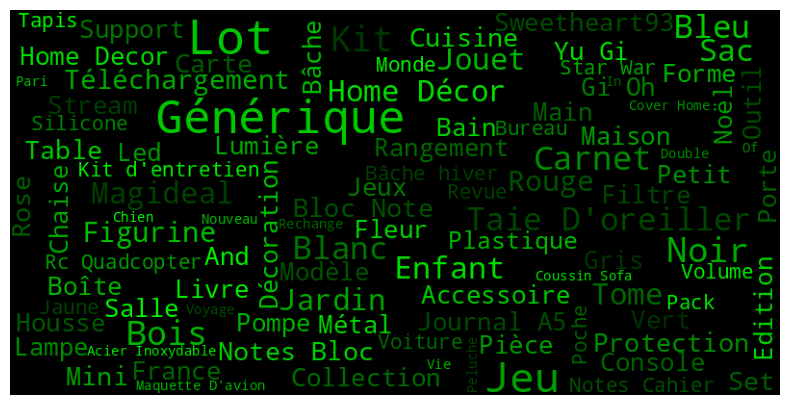

In [60]:
import matplotlib.pyplot as plt

# Générer et afficher le nuage de mots

plt.figure(figsize=(13,5))
plt.imshow(wc1)
plt.axis('off')
plt.show()

Le français semble largement majoritaire, suivi par l'anglais.

##### Variable : description

(Cellules commentées car elles mettent du temps à charger.)

In [61]:
# wc = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [62]:
# text = ' '.join(X.description.dropna())
# len(text)

In [63]:
# # Dure 12s.
# wc.generate(text)

In [64]:
# plt.figure(figsize=(13,5))
# plt.imshow(wc)
# plt.axis('off')
# plt.show()

### Images

#### Load

In [65]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

def load_image(row, color=True, folder = '../../Dataset/images/image_train'):
    filename = f"image_{row.imageid}_product_{row.productid}.jpg"
    path = Path(folder) / filename
    if color:
        color_arg = cv2.IMREAD_COLOR
    else:
        color_arg = cv2.IMREAD_GRAYSCALE
    img_color = cv2.imread(str(path), color_arg)
    if img_color is None:
        raise ValueError
    return img_color

#### Display

In [66]:
def display_images(rows,nrow,ncol,axis=False):
    n = len(rows)
    if n > nrow*ncol:
        print('(`rows` is too long for this grid. Not showing all values.)')
        n = nrow*ncol
    plt.figure(figsize=(13,8))
    for k in range(n):
        plt.subplot(nrow,ncol,k+1)
        row = rows.iloc[k]
        plt.imshow(load_image(row))
        if not axis:
            plt.axis('off')

Show random images from the dataset.

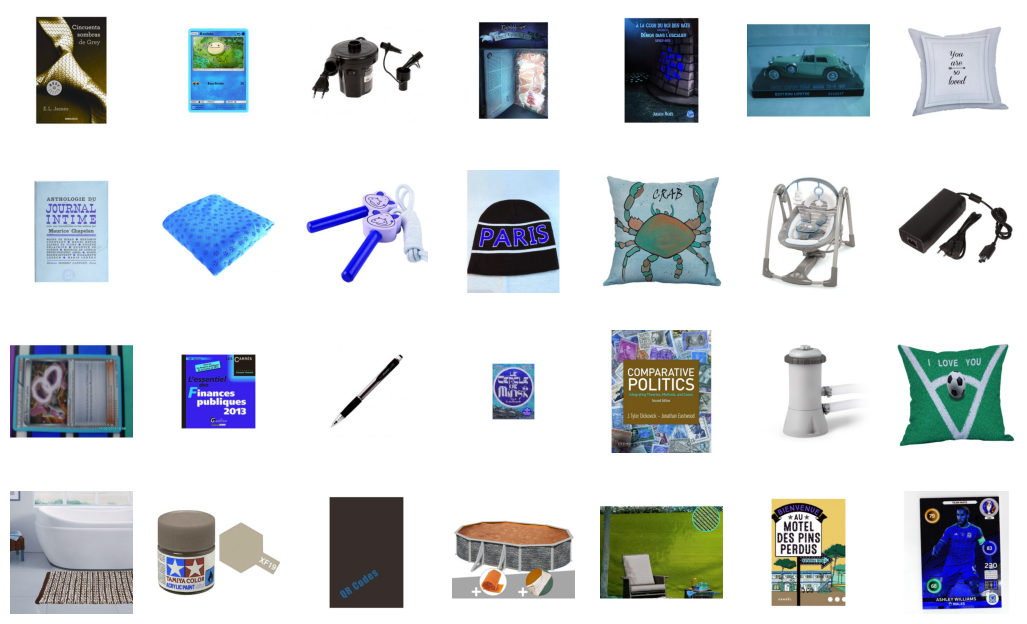

In [67]:
nrow = 4
ncol = 7
n = nrow*ncol
rows = X.sample(n)
display_images(rows,nrow,ncol)

Bien que les images aient le même nombre de pixels, certaines sur fond blanc ont des couleurs sur seulement une petite partie de l'image. On peut envisager de s'intéresser aux pixels non blancs. Certes, certaines images ont un fond différent, mais elles semblent plus rares.

#### Pixel count

In [68]:
def count_pixels(row, folder = '../../Dataset/images/image_train'):
    img_color = load_image(row, folder = folder)
    return img_color.shape

On regarde les dimensions d'images aléatoires du jeu de données. (Regarder toutes les images met longtemps à charger.) Elles ont toutes les mêmes dimensions.

In [69]:
X.sample(100).apply(count_pixels,axis=1).unique()

array([(500, 500, 3)], dtype=object)

In [70]:
500*500

250000

In [71]:
# # Regarde pour toutes les lignes, donc met 2m30 à charger. Résultat : array([(500, 500, 3)], dtype=object).
# X.apply(count_pixels,axis=1).unique()

#### Create features

##### Non-white pixels

In [72]:
def get_content_bounding_box(row, threshold=254, folder = '../../Dataset/images/image_train'):
    # Load image, ensure it's grayscale for finding coordinates
    img = load_image(row, color=False, folder = folder)

    # Find all non-white pixels. A threshold of 254 handles JPEG artifacts.
    # (Pure white is 255, but compression can create values like 254)
    mask = img < threshold

    # Le compte de pixels est la somme des pixels 'True' (ou 1) dans le masque.
    essential_pixel_count = np.sum(mask)

    non_white_pixels = np.argwhere(mask)  # Returns (row, col) coordinates

    if non_white_pixels.size == 0:
        return 0, 0, 0, 0, 0  # White image

    # np.argwhere gives (row, col) which corresponds to (y, x)
    y_coords = non_white_pixels[:, 0]
    x_coords = non_white_pixels[:, 1]

    y_min, y_max = y_coords.min(), y_coords.max()
    x_min, x_max = x_coords.min(), x_coords.max()

    return essential_pixel_count, x_min, y_min, x_max, y_max

In [73]:
# # Dure 4mn10.
# coords = df.apply(get_content_bounding_box,axis=1)

In [74]:
# coords[:4]

In [75]:
# col_names = ['essential_pixel_count', 'x_min', 'y_min', 'x_max', 'y_max']
# coords_df = pd.DataFrame(coords.tolist(), index=df.index, columns=col_names)
# coords_df

In [76]:
# coords_df.info()

In [77]:
# df=df.drop(columns=col_names)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   designation      84916 non-null  object
 1   description      55116 non-null  object
 2   productid        84916 non-null  int64 
 3   imageid          84916 non-null  int64 
 4   prdtypecode      84916 non-null  int64 
 5   len_designation  84916 non-null  int64 
 6   len_description  84916 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 7.2+ MB


In [79]:
# df = df.join(coords_df)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   designation      84916 non-null  object
 1   description      55116 non-null  object
 2   productid        84916 non-null  int64 
 3   imageid          84916 non-null  int64 
 4   prdtypecode      84916 non-null  int64 
 5   len_designation  84916 non-null  int64 
 6   len_description  84916 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 7.2+ MB


In [81]:
# df['essential_width'] = df.x_max - df.x_min + 1

In [82]:
# df['essential_height'] = df.y_max - df.y_min + 1

In [83]:
# df['essential_aspect_ratio'] = df.essential_width / df.essential_height

In [84]:
# df['essential_area'] = df.essential_width * df.essential_height

In [85]:
# # Mesure à quel point la partie non blanche ressemble à un rectangle plein.
# df['rectangleness'] = df.essential_pixel_count / df.essential_area

##### Color features

In [86]:
def get_image_color_stats(row, folder = '../../Dataset/images/image_train') -> dict:
    """
    Charge une image une seule fois et calcule rapidement les statistiques
    de couleur (moyenne, écart-type) et de niveaux de gris.

    Args:
        image_path (str): Le chemin vers le fichier image.

    Returns:
        dict: Un dictionnaire contenant les features calculées.
    """
    # 1. Charger l'image en couleur (BGR par défaut avec OpenCV)
    img_color = load_image(row, color=True, folder = folder)

    # Gérer le cas où l'image n'a pas pu être chargée
    if img_color is None:
        # Renvoyer un dictionnaire avec des zéros pour maintenir la structure des données
        keys = ['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b',
                'mean_gray', 'std_gray']
        return {key: 0 for key in keys}

    # 2. Calculer les stats pour les canaux de couleur
    # OpenCV charge en BGR, donc l'ordre est Bleu, Vert, Rouge
    mean_b, mean_g, mean_r = np.mean(img_color, axis=(0, 1))
    std_b, std_g, std_r = np.std(img_color, axis=(0, 1))

    # 3. Convertir en niveaux de gris (opération en mémoire, très rapide)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # 4. Calculer les stats pour les niveaux de gris
    mean_gray = np.mean(img_gray)
    std_gray = np.std(img_gray)

    return {
        'mean_r': mean_r,
        'mean_g': mean_g,
        'mean_b': mean_b,
        'std_r': std_r,
        'std_g': std_g,
        'std_b': std_b,
        'mean_gray': mean_gray,
        'std_gray': std_gray
    }

In [87]:
df.sample(3).apply(get_image_color_stats,axis=1)

37366    {'mean_r': 217.923356, 'mean_g': 218.225156, '...
38753    {'mean_r': 207.283472, 'mean_g': 207.256124, '...
70909    {'mean_r': 180.024508, 'mean_g': 186.432516, '...
dtype: object

In [88]:
# # Dure 2m47

# from joblib import Parallel, delayed

# print("Démarrage de l'extraction de features en parallèle...")
# # n_jobs=-1 utilise tous les coeurs disponibles
# # backend="loky" est plus robuste pour les processus complexes
# results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
#     delayed(get_image_color_stats)(row) for row in df.itertuples(index=False)
# )
# print("Extraction terminée.")

In [89]:
# results[:5]

In [90]:
# len(results)

In [91]:
# # Convertir la liste de résultats (dictionnaires) en un DataFrame
# image_features_df = pd.DataFrame(results, index=df.index)

In [92]:
# image_features_df.info()

In [93]:
# image_features_df.iloc[:5]

In [94]:
# df = df.join(image_features_df)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   designation      84916 non-null  object
 1   description      55116 non-null  object
 2   productid        84916 non-null  int64 
 3   imageid          84916 non-null  int64 
 4   prdtypecode      84916 non-null  int64 
 5   len_designation  84916 non-null  int64 
 6   len_description  84916 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 7.2+ MB


#### Load extended df

In [96]:
# Le code suivant dans un notebook permet d'autoriser les imports de fichiers python de ce repo.

import sys
import os

# Ce code cherche le dossier racine en remontant dans l'arborescence
# jusqu'à ce qu'il trouve le dossier 'src'.
# Cela le rend indépendant de l'endroit où vous lancez le notebook.
try:
    # On part du dossier du notebook
    notebook_dir = os.path.dirname(__file__)
except NameError:
    # __file__ n'existe pas en mode interactif, on utilise le répertoire de travail
    notebook_dir = os.getcwd()

# On remonte jusqu'à trouver un dossier contenant 'src'
project_root = notebook_dir
while not os.path.isdir(os.path.join(project_root, 'src')):
    parent_dir = os.path.dirname(project_root)
    if parent_dir == project_root: # On a atteint la racine du système
        raise FileNotFoundError("Impossible de trouver le dossier 'src'. Vérifiez la structure du projet.")
    project_root = parent_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Ajout de '{project_root}' au sys.path .")

Ajout de '/home/val/Documents/Dev/DataScientest/Rakuten' au sys.path .


In [97]:
from src.preprocessing.core import load_extended_df
df=load_extended_df(path='../../Dataset2/df.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             84916 non-null  object 
 1   description             55116 non-null  object 
 2   productid               84916 non-null  int64  
 3   imageid                 84916 non-null  int64  
 4   prdtypecode             84916 non-null  int64  
 5   x_min                   84916 non-null  int64  
 6   y_min                   84916 non-null  int64  
 7   x_max                   84916 non-null  int64  
 8   y_max                   84916 non-null  int64  
 9   mean_r                  84916 non-null  float64
 10  mean_g                  84916 non-null  float64
 11  mean_b                  84916 non-null  float64
 12  std_r                   84916 non-null  float64
 13  std_g                   84916 non-null  float64
 14  std_b                   84916 non-null  flo

#### Images triées par densité (nombre de pixels non blancs)

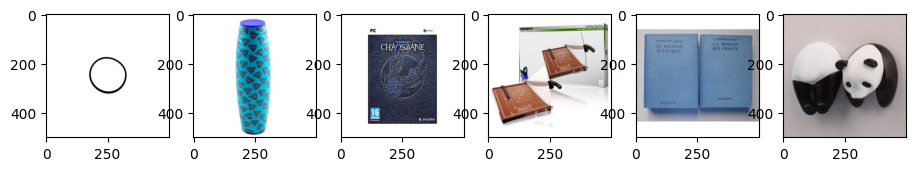

In [ ]:
# De densité faible à haute
rows = []
for a in np.linspace(0.01,1,6):
    rows.append(df[(df.essential_pixel_count < df.essential_pixel_count.quantile(a)) & (df.essential_pixel_count >= df.essential_pixel_count.quantile(a-.01))].sample(1))
rows = pd.concat(rows)
display_images(rows,1,7,axis=True)

#### Images selon rectangularité

Mesure à quel point le produit remeplit son rectangle délimitant, en supposant que "blanc"="vide" (niveau de gris 254 ou 255).

In [ ]:
# Images à rectangularité faible mais non toutes blanches
rows = df[(df.rectangleness < .06) & (df.rectangleness > 0)]
rows.shape

(11, 25)

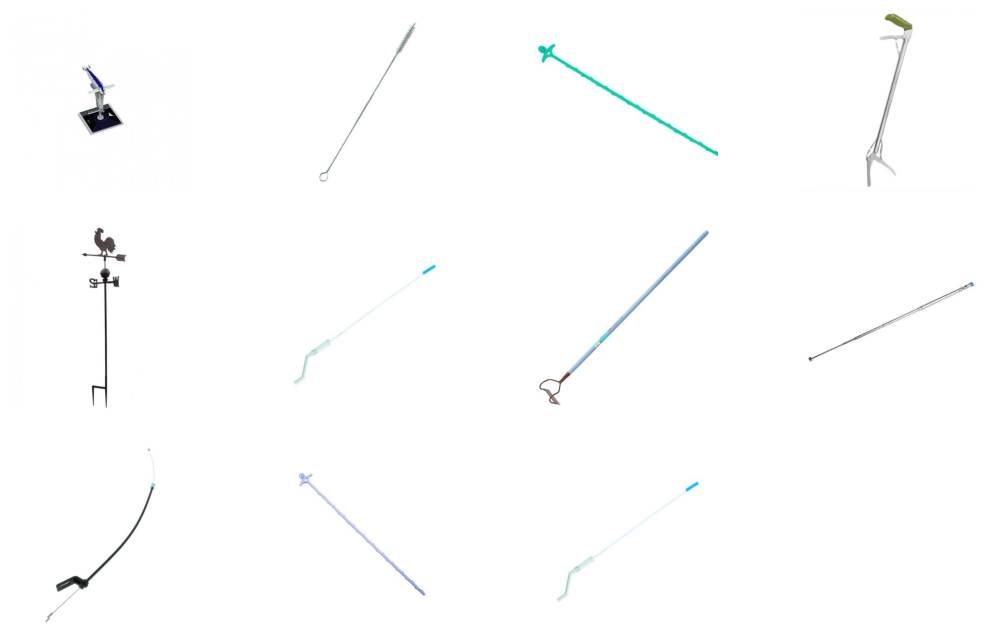

In [ ]:
display_images(rows,3,4)

In [ ]:
# Images à rectangularité moyenne
a=.40
rows = df[(df.rectangleness < a) & (df.rectangleness > a-.01)]
rows.shape

(483, 25)

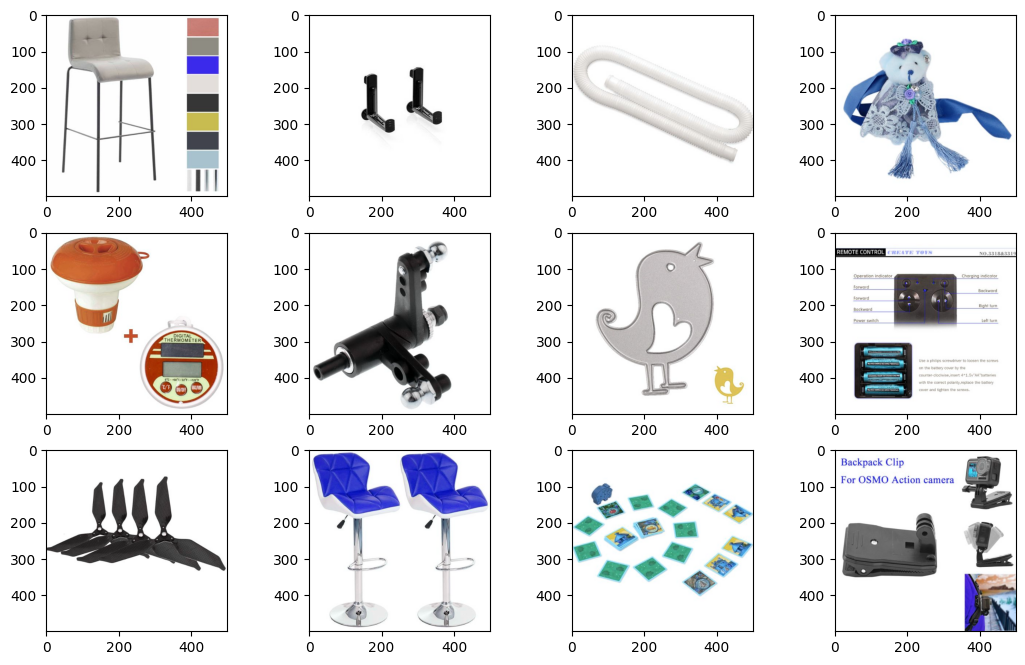

In [ ]:
display_images(rows[:12],3,4,axis=True)

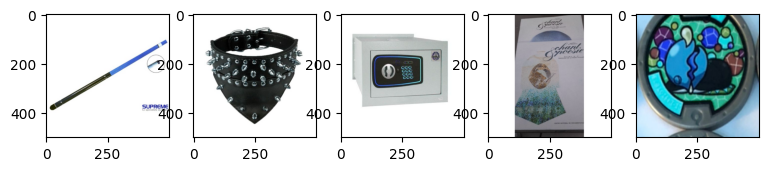

In [ ]:
# De rectangularité faible à haute (à quel point le produit ressemble à un rectangle plein, en supposant que "blanc"="vide")
rows = []
for a in np.linspace(0.01,1,5):
    rows.append(df[(df.rectangleness < df.rectangleness.quantile(a)) & (df.rectangleness >= df.rectangleness.quantile(a-.01))].sample(1))
rows = pd.concat(rows)
display_images(rows,1,7,axis=True)

#### Analyze image features
Nombre de valeurs uniques et type de chaque colonne.

In [98]:
for col in df.columns[0:]:
    print(f"{col} {df[col].nunique()} {df[col].dtype}")

designation 82265 object
description 47506 object
productid 84916 int64
imageid 84916 int64
prdtypecode 27 int64
x_min 235 int64
y_min 247 int64
x_max 243 int64
y_max 250 int64
mean_r 79121 float64
mean_g 79131 float64
mean_b 79129 float64
std_r 79222 float64
std_g 79222 float64
std_b 79222 float64
mean_gray 79136 float64
std_gray 79222 float64
essential_pixel_count 58677 int64
len_designation 239 int64
len_description 3718 int64
essential_width 464 int64
essential_height 478 int64
essential_aspect_ratio 14654 float64
essential_area 11721 int64
rectangleness 66737 float64


Les variables essential_area et essential_pixel_count ne sont pas redondantes : leur ratio rectangleness n'est pas constant.

In [99]:
df['rectangleness'].describe()

count    84916.000000
mean         0.784463
std          0.226996
min          0.000000
25%          0.617573
50%          0.886712
75%          0.978792
max          1.000000
Name: rectangleness, dtype: float64

In [100]:
df['essential_pixel_count'].describe()

count     84916.000000
mean     127253.771739
std       67421.188364
min           0.000000
25%       70043.000000
50%      122333.000000
75%      181928.250000
max      250000.000000
Name: essential_pixel_count, dtype: float64

In [101]:
# mean_[rgb] : teinte globale de l'image
# mean_gray : luminosité de l'image
# std_[rgb] : contraste, variété des couleurs
# std_gray : variété de la luminosité
df.loc[:,'mean_r':].describe()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_gray,std_gray,essential_pixel_count,len_designation,len_description,essential_width,essential_height,essential_aspect_ratio,essential_area,rectangleness
count,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000
mean,199.838750,195.519166,191.964443,61.508723,63.587782,66.137707,196.406031,62.060626,127253.771739,70.163303,524.555926,392.887901,396.707852,1.089901,159332.823838,0.784463
std,40.888817,41.798584,44.358478,24.263654,22.944080,23.814731,40.954589,22.138018,67421.188364,36.793383,754.893905,110.350117,106.722099,0.759541,63355.201300,0.226996
min,1.701404,0.938964,1.689608,0.000000,0.000000,0.000000,2.440544,0.000000,0.000000,11.000000,0.000000,1.000000,1.000000,0.048000,1.000000,0.000000
25%,174.469133,168.015495,162.310952,43.405259,46.872417,48.592731,169.294558,46.012848,70043.000000,43.000000,0.000000,320.000000,320.000000,0.741984,118728.000000,0.617573
50%,208.281432,203.418850,200.491772,62.775438,65.205241,68.744376,204.139580,63.441236,122333.000000,64.000000,231.000000,416.000000,420.000000,1.000000,171500.000000,0.886712
75%,232.894265,229.547917,228.709854,79.872333,80.888554,84.621927,229.664644,78.658299,181928.250000,90.000000,823.000000,500.000000,500.000000,1.281250,199680.000000,0.978792
max,255.000000,255.000000,255.000000,126.253580,126.253580,126.253580,255.000000,126.253580,250000.000000,250.000000,12451.000000,500.000000,500.000000,20.833333,250000.000000,1.000000


4 images sont toutes blanches.

In [102]:
rows_with_white_image = df[df.essential_pixel_count == 0]
rows_with_white_image

,designation,description,productid,imageid,prdtypecode,x_min,y_min,x_max,y_max,mean_r,...,mean_gray,std_gray,essential_pixel_count,len_designation,len_description,essential_width,essential_height,essential_aspect_ratio,essential_area,rectangleness
37124,Römer Britax Kid Ii Cosmos Black - Siège Auto,Römer Britax KID II Cosmos Black - Siège Auto,884747735,1142089742,1320,0,0,0,0,255.0,...,255.0,0.0,0,45,45,1,1,1.0,1,0.0
52327,Minions Peluche Electronique 25 Cm - Stuart,MINIONS - Retrouve l&#39;univers drôle et déja...,3793782107,1302249863,1280,0,0,0,0,255.0,...,255.0,0.0,0,43,241,1,1,1.0,1,0.0
79708,Blagdon extract of barley straw treatment (siz...,None,1892606336,1137819811,2583,0,0,0,0,255.0,...,255.0,0.0,0,57,0,1,1,1.0,1,0.0
80859,Bledina Mini Lactes Nature Sans Sucre - 6 X 55g,BLEDINA Mini lactes nature sans sucre - 6 x 55...,3894592691,1271791205,1940,0,0,0,0,255.0,...,255.0,0.0,0,47,279,1,1,1.0,1,0.0


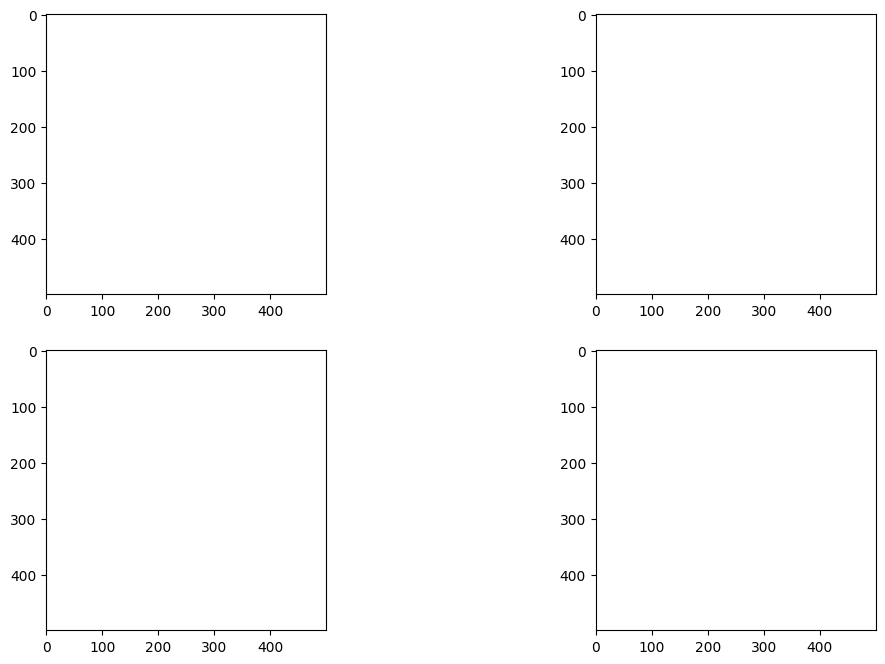

In [103]:
display_images(rows_with_white_image,2,2,axis=True)

#### Correlation heatmap

<Axes: >

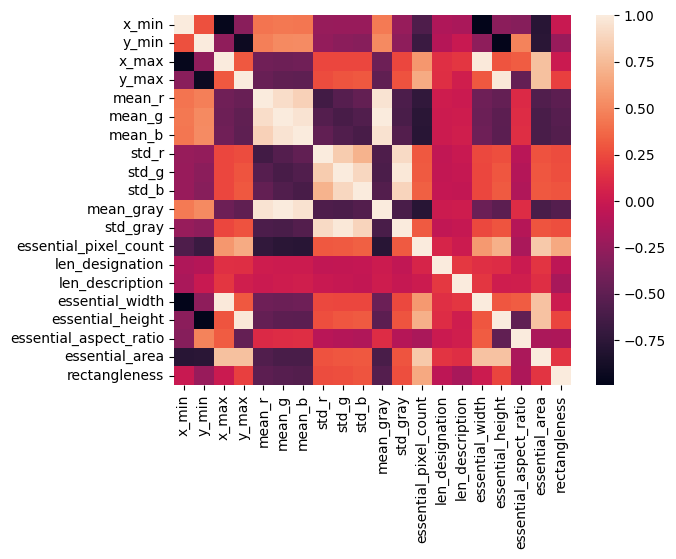

In [104]:
sns.heatmap(df.loc[:,'x_min':].corr())

Les variables mean_* sont très corrélées : pour chaque image, l'intensité moyenne de couleur tend à être similaire sur les trois canaux RGB ainsi qu'en niveaux de gris.

Les variables mean_* ont tendance à être anti-corrélées avec les variables venant de essential_pixel_count (c'est normal vu qu'elle compte les pixels non blancs, qui augmentent les moyennes de couleurs).

Les variables std_* sont très corrélées.

On pourra envisager de retirer certaines variables (anti-)corrélées pour voir si ça améliore la performance des modèles.

(La variable cible n'est pas dans ce graphique car elle est catégorielle non ordinale.)

#### Par catégorie produit

##### Couleur, luminosité : moyennes

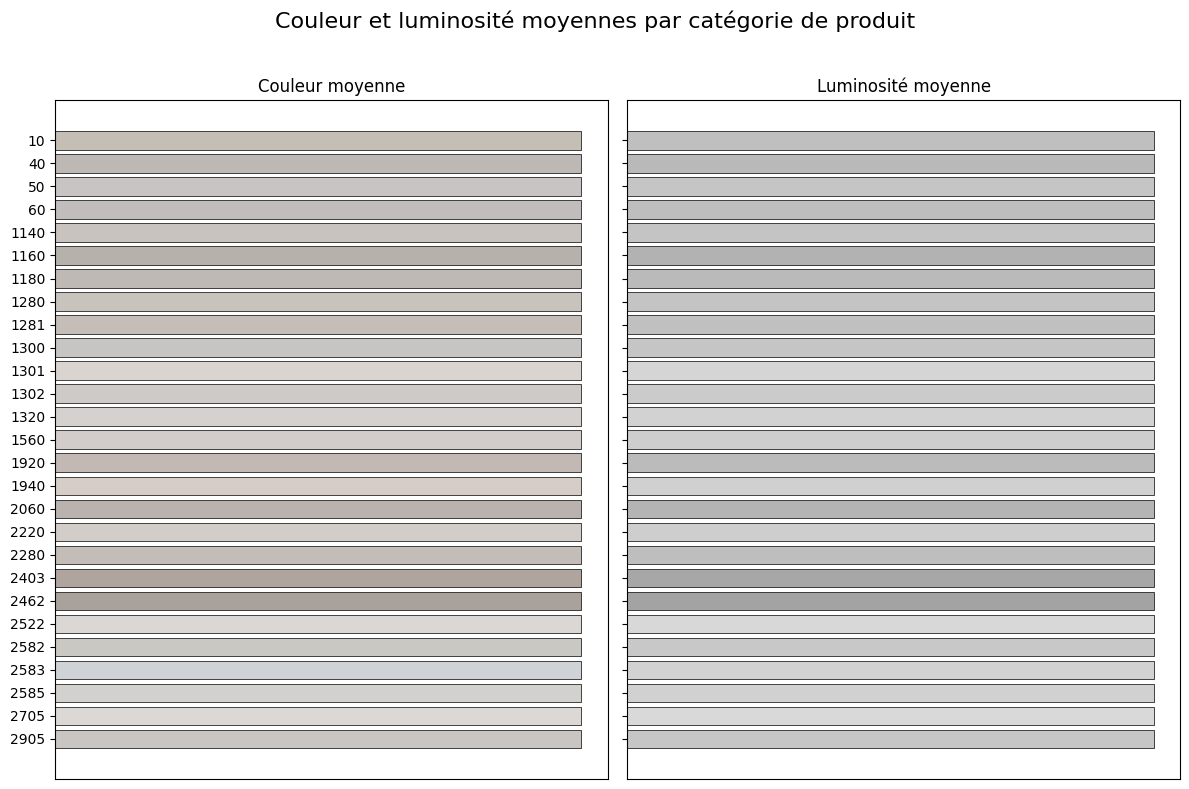

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Préparer les données ---
# Grouper une seule fois pour l'efficacité
avg_stats = df.groupby('prdtypecode')[['mean_r', 'mean_g', 'mean_b', 'mean_gray']].mean()

# Normaliser les valeurs de couleur et de gris pour l'affichage (entre 0 et 1)
avg_colors_normalized = avg_stats[['mean_r', 'mean_g', 'mean_b']] / 255.0
avg_gray_normalized = avg_stats[['mean_gray', 'mean_gray', 'mean_gray']] / 255.0 # Tripler le gris

# Obtenir les labels des catégories
category_labels = avg_stats.index.astype(str)

# --- Créer la figure et les subplots ---
# Définir une figure avec 1 ligne et 2 colonnes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Couleur et luminosité moyennes par catégorie de produit", fontsize=16)

# --- Subplot 1: Couleur moyenne ---
ax1.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_colors_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax1.set_title("Couleur moyenne")
ax1.set_xticks([]) # Masquer les graduations de l'axe x
ax1.invert_yaxis() # Inverser l'axe y pour un ordre naturel

# --- Subplot 2: Luminosité moyenne ---
ax2.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_gray_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax2.set_title("Luminosité moyenne")
ax2.set_xticks([]) # Masquer les graduations de l'axe x

# Ajuster l'espacement et afficher le graphique
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuster pour faire de la place au titre principal
plt.show()

Le graphique ci-dessus illustre que la couleur et la luminosité moyenne des images aident bien à différencier les catégories de produits. On observe à nouveau la corrélation entre mean_[rgb] et mean_gray.

In [148]:
# Préparation des données : passer d'un format large à un format long
df_melted = df.melt(
    id_vars=['prdtypecode'],
    value_vars=['mean_r', 'mean_g', 'mean_b', 'mean_gray'],
    var_name='channel', # Nom de la nouvelle colonne pour les canaux
    value_name='mean_value' # Nom de la nouvelle colonne pour les valeurs
)
df_melted

,prdtypecode,channel,mean_value
0,10,mean_r,251.474248
1,2280,mean_r,233.709468
2,50,mean_r,249.347872
3,1280,mean_r,169.912284
4,2705,mean_r,225.420976
...,...,...,...
339659,40,mean_gray,162.510008
339660,2583,mean_gray,155.835820
339661,2280,mean_gray,234.460652
339662,1560,mean_gray,209.978628


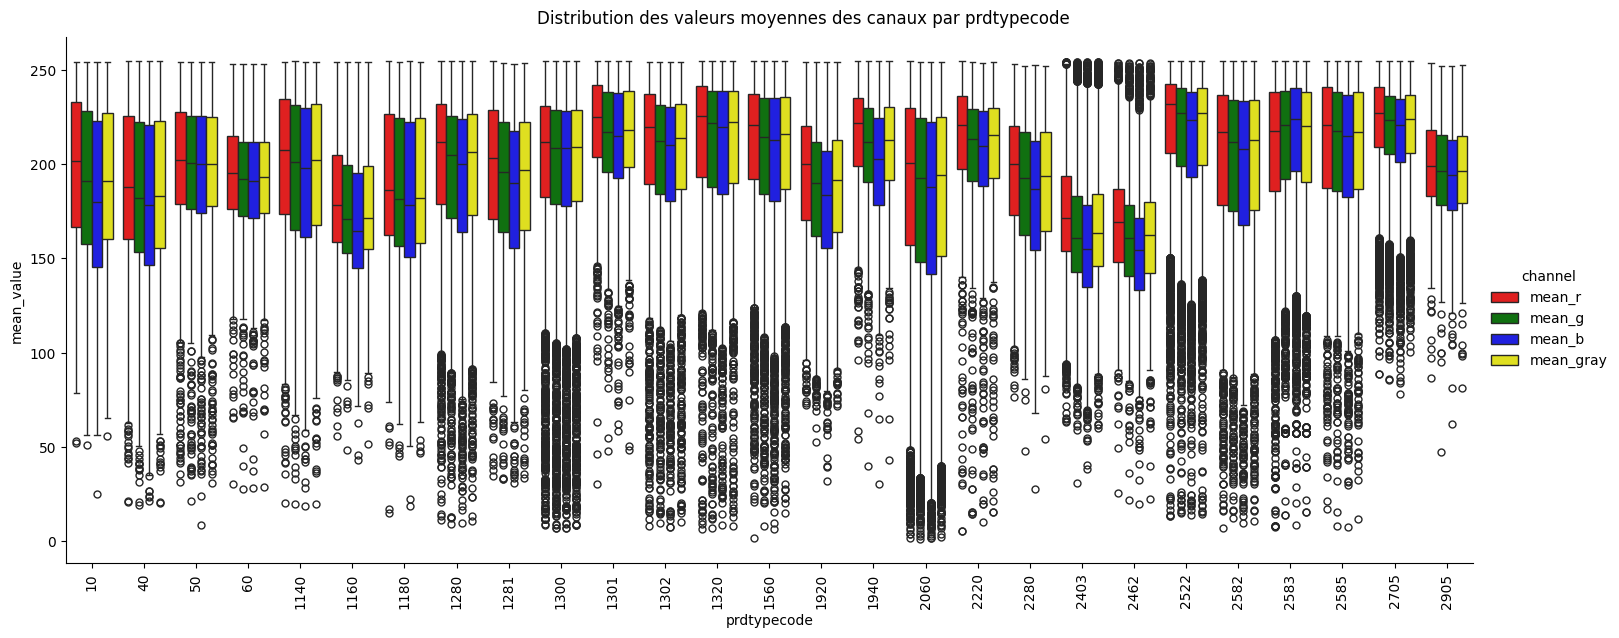

In [ ]:
# Utiliser catplot de Seaborn pour créer des boxplots pour chaque canal et chaque catégorie
g = sns.catplot(
    data=df_melted,
    x='prdtypecode',
    y='mean_value',
    hue='channel',
    kind='box',  # 'bar' ou 'violin' sont aussi de bonnes options
    height=6,
    aspect=2.5,
    palette={'mean_r': 'red', 'mean_g': 'green', 'mean_b': 'blue', 'mean_gray': 'yellow'}
)

g.fig.suptitle("Distribution des valeurs moyennes des canaux par prdtypecode", y=1.02)
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité
plt.show()

Même remarque, mais ce graphique est plus précis. (La couleur et la luminosité moyenne des images aident bien à différencier les catégories de produits. On observe encore la corrélation entre mean_[rgb] et mean_gray.)

##### Couleur, luminosité : écarts-types

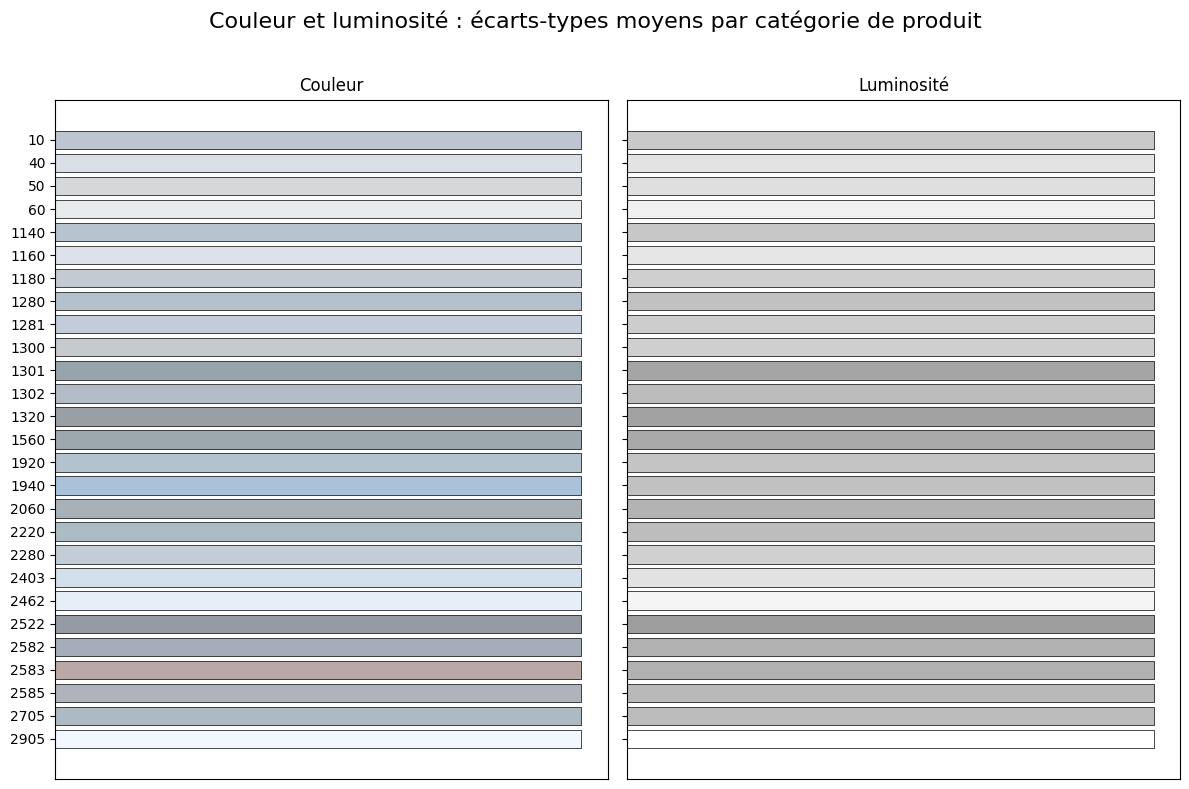

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Préparer les données ---
# Grouper une seule fois pour l'efficacité
avg_stats = df.groupby('prdtypecode')[['std_r', 'std_g', 'std_b', 'std_gray']].mean()

avg_colors_normalized = avg_stats[['std_r', 'std_g', 'std_b']]
avg_gray_normalized = avg_stats[['std_gray', 'std_gray', 'std_gray']] # Tripler le gris
# Normaliser les valeurs de couleur et de gris pour l'affichage (entre 0 et 1)
avg_colors_normalized /= avg_colors_normalized.max().max()
avg_gray_normalized /= avg_gray_normalized.max().max()

# Obtenir les labels des catégories
category_labels = avg_stats.index.astype(str)

# --- Créer la figure et les subplots ---
# Définir une figure avec 1 ligne et 2 colonnes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Couleur et luminosité : écarts-types moyens par catégorie de produit", fontsize=16)

# --- Subplot 1: Couleur moyenne ---
ax1.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_colors_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax1.set_title("Couleur")
ax1.set_xticks([]) # Masquer les graduations de l'axe x
ax1.invert_yaxis() # Inverser l'axe y pour un ordre naturel

# --- Subplot 2: Luminosité moyenne ---
ax2.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_gray_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax2.set_title("Luminosité")
ax2.set_xticks([]) # Masquer les graduations de l'axe x

# Ajuster l'espacement et afficher le graphique
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuster pour faire de la place au titre principal
plt.show()

Le graphique ci-dessus des écarts-types est plus varié que le graphique des moyennes. Ceci suggère que les écarts-types des canaux sont un moyen plus puissant de distinguer les catégories produits. En termes plus simples, le contraste des images semble bien aider à distinguer les catégories produits.

On observe aussi la corrélation entre std_[rgb] et std_gray.

(Pour clarifier le sens du graphique : on considère l'écart-type d'un canal d'une image donnée, puis on prend la moyenne de ces écarts-types pour une catégorie produit. On procède ainsi pour chaque catégorie.)

In [153]:
# Préparation des données : passer d'un format large à un format long
df_melted = df.melt(
    id_vars=['prdtypecode'],
    value_vars=['std_r', 'std_g', 'std_b', 'std_gray'],
    var_name='channel', # Nom de la nouvelle colonne pour les canaux
    value_name='std_value' # Nom de la nouvelle colonne pour les valeurs
)

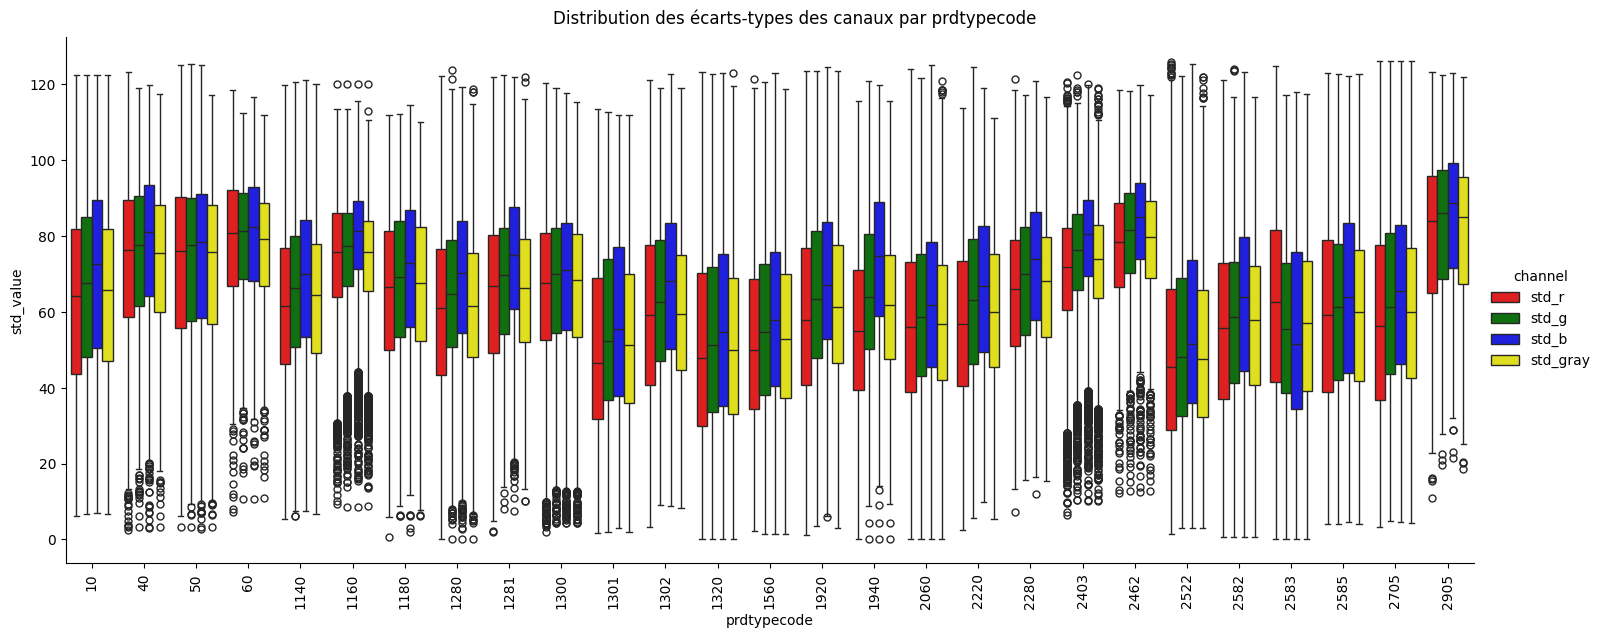

In [154]:
# Utiliser catplot de Seaborn pour créer des boxplots pour chaque canal et chaque catégorie
g = sns.catplot(
    data=df_melted,
    x='prdtypecode',
    y='std_value',
    hue='channel',
    kind='box',  # 'bar' ou 'violin' sont aussi de bonnes options
    height=6,
    aspect=2.5,
    palette={'std_r': 'red', 'std_g': 'green', 'std_b': 'blue', 'std_gray': 'yellow'}
)

g.fig.suptitle("Distribution des écarts-types des canaux par prdtypecode", y=1.02)
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité
plt.show()

Les écarts-types des canaux semblent avoir moins d'outliers que les moyennes des canaux. On observe à nouveau la corrélation entre std_[rgb] et std_gray.
On voit à nouveau que les écarts-types des canaux semblent aider à distinguer les catégories produits.

##### Coordonnées

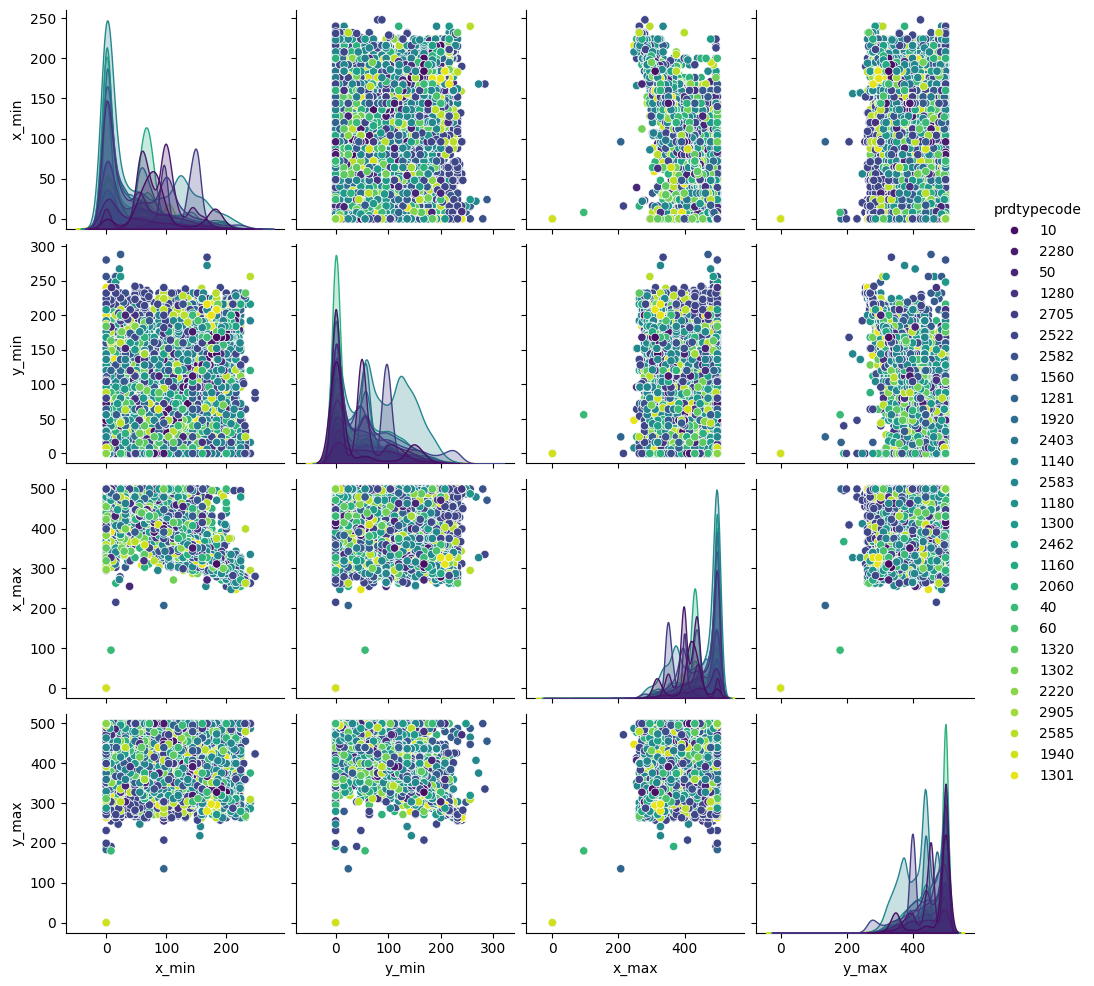

In [ ]:
# Dure 32s.
colnames = df.loc[:,'x_min':'y_max'].columns.tolist() + ['prdtypecode']

df_for_plot = df[colnames].copy()

df_for_plot['prdtypecode'] = df_for_plot['prdtypecode'].astype(str)

sns.pairplot(data=df_for_plot, hue='prdtypecode', palette='viridis') # 'viridis' est une palette qui gère bien de nombreuses catégories
plt.show()

Ci-dessus, les graphiques diagonaux indiquent que ces variables aident bien à distinguer la catégorie produit. Les autres graphiques ne montrent pas clairement de relation entre ces couples de variables selon la catégorie produit. Ceci dit, on observe parfois un groupement jaune, suggérant que pour la catégorie 1301, il peut y avoir un couplage entre ces variables. 

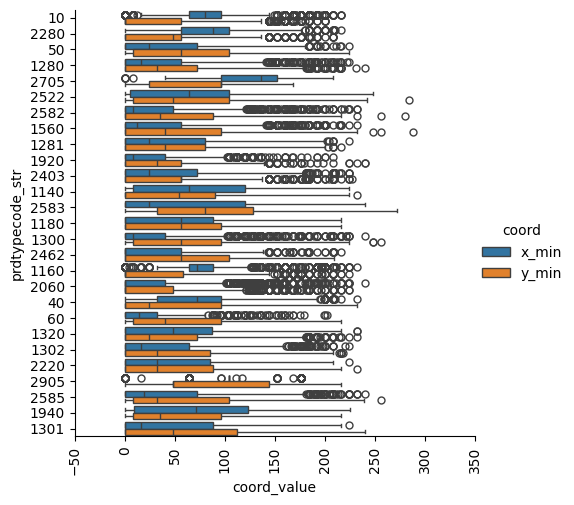

In [157]:
df['prdtypecode_str'] = df['prdtypecode'].astype(str)
df_melted = df.melt(
    id_vars=['prdtypecode_str'],
    value_vars=['x_min', 'y_min'], # , 'x_max', 'y_max'
    var_name='coord', # Nom de la nouvelle colonne pour les variables
    value_name='coord_value' # Nom de la nouvelle colonne pour les valeurs
)
g = sns.catplot(y = "prdtypecode_str", x = "coord_value", hue='coord', kind = "box" , data = df_melted, aspect=1) #.set(xlim=(0, 3)) # TODO
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité


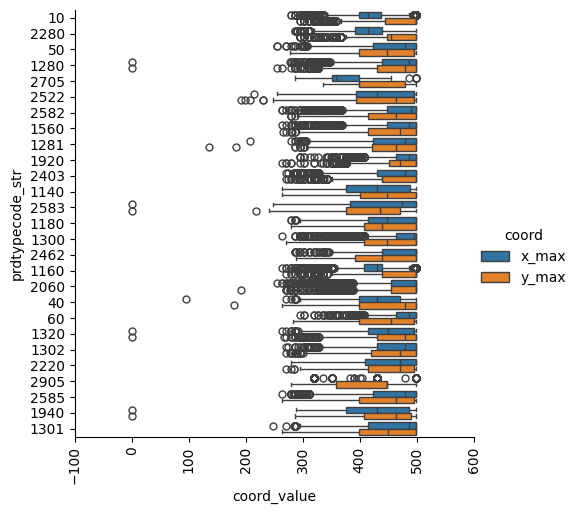

In [160]:
df['prdtypecode_str'] = df['prdtypecode'].astype(str)
df_melted = df.melt(
    id_vars=['prdtypecode_str'],
    value_vars=['x_max', 'y_max'],
    var_name='coord', # Nom de la nouvelle colonne pour les variables
    value_name='coord_value' # Nom de la nouvelle colonne pour les valeurs
)
g = sns.catplot(y = "prdtypecode_str", x = "coord_value", hue='coord', kind = "box" , data = df_melted, aspect=1) #.set(xlim=(0, 3)) # TODO
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité

Les coordonnées du rectangle délimitant la partie non blanche semblent aider à distinguer les catégories. Ça correspond à l'impression qu'on a en regardant des images du jeu de données.

##### Pixels non blancs

In [ ]:
df['prdtypecode_str'] = df['prdtypecode'].astype(str)

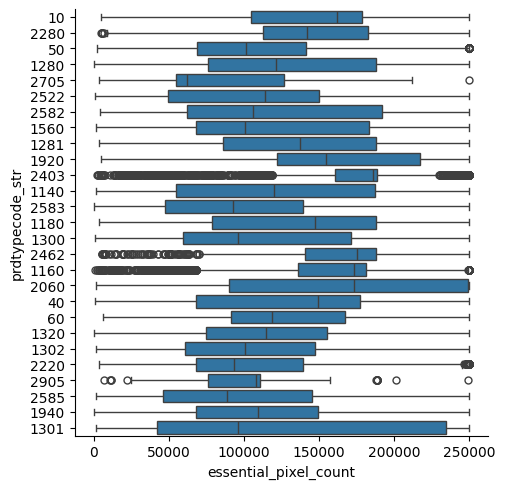

In [125]:
sns.catplot (y = "prdtypecode_str", x = "essential_pixel_count", kind = "box" , data = df)

Le nombre de pixels non blancs sur l'image produit semble pertinent pour distinguer les catégories. Par exemple, on peut s'attendre à ce qu'un balai (dont le manche est relativement fin) occupe moins de pixels qu'un matelas.

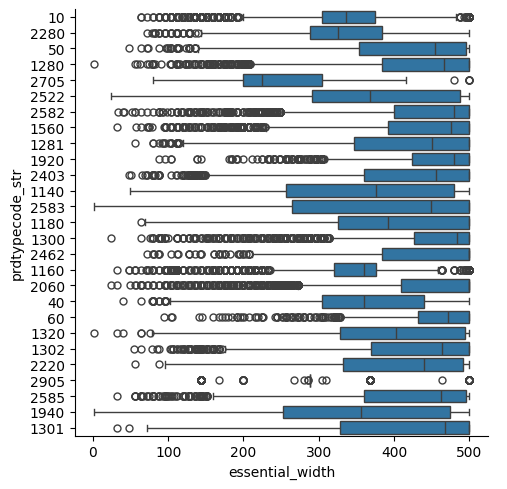

In [126]:
sns.catplot(x = "essential_width", y = "prdtypecode_str", kind = "box" , data = df)

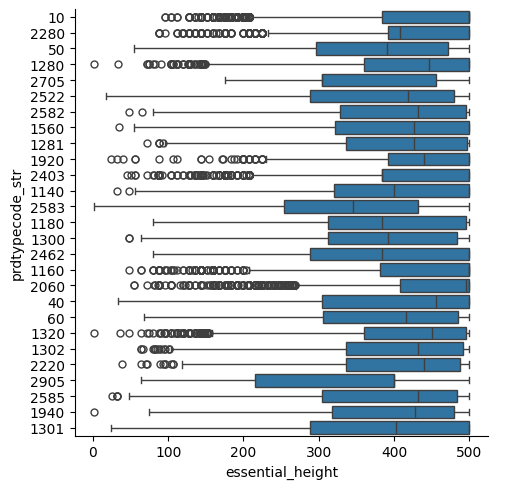

In [127]:
sns.catplot(x = "essential_height", y = "prdtypecode_str", kind = "box" , data = df)

Même remarques pour les graphiques ci-dessus.

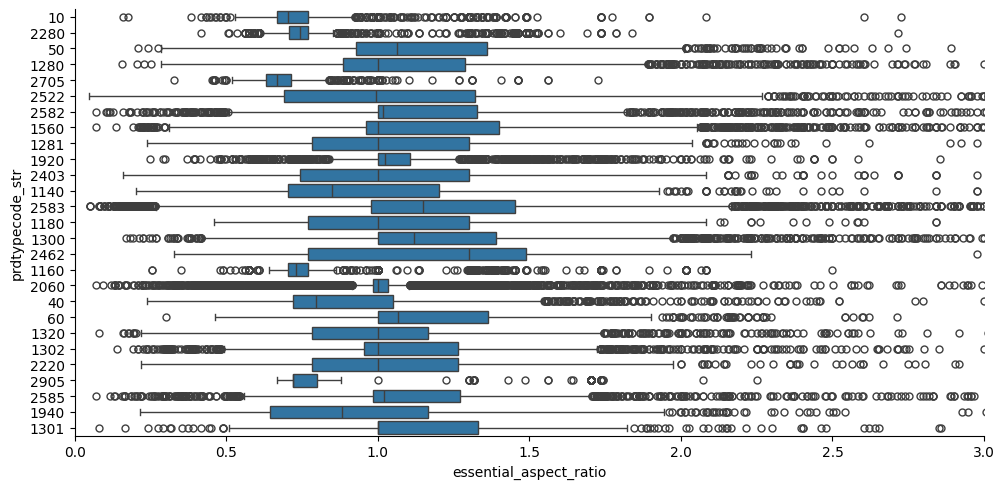

In [139]:
sns.catplot(x = "essential_aspect_ratio", y = "prdtypecode_str", kind = "box" , data = df,aspect=2).set(xlim=(0, 3))

La variable mesure quel point la partie non blanche de l'image est en format paysage (droite du graphique) plutôt que portrait (gauche du graphique).

On distingue moins les différences de distribution entre les catégories, mais elles sont présentes. Par exemple, la catégorie 10 semble préférer le format portrait plus que la majorité des catégories.

(Le graphique est tronqué à 3 sur l'axe horizontal pour améliorer la lisibilité, mais il y a des outliers avec un essential_aspect_ratio de plus de 20.)

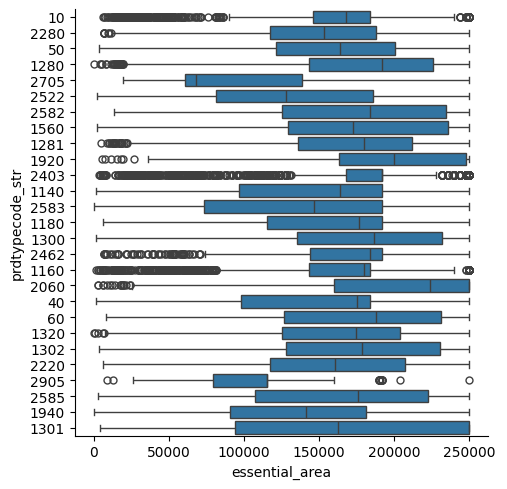

In [141]:
sns.catplot(x = "essential_area", y = "prdtypecode_str", kind = "box" , data = df, aspect=1) #.set(xlim=(0, 3))

L'aire du rectangle délimitant la partie non blanche de l'image semble aider à distinguer les catégories.

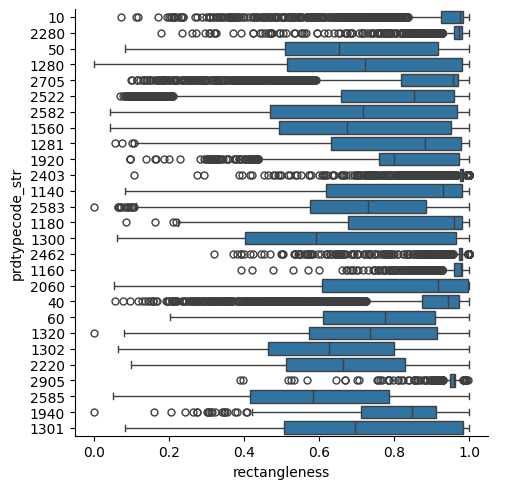

In [ ]:
sns.catplot(x = "rectangleness", y = "prdtypecode_str", kind = "box" , data = df, aspect=1) #.set(xlim=(0, 3))

Cette variable mesure à quel point la partie non blanche remplit son rectangle délimitant.

Elle semble aider à distinguer les catégories.

## Save df

In [114]:
print(df.columns.tolist())

['designation', 'description', 'productid', 'imageid', 'prdtypecode', 'x_min', 'y_min', 'x_max', 'y_max', 'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b', 'mean_gray', 'std_gray', 'essential_pixel_count', 'len_designation', 'len_description', 'essential_width', 'essential_height', 'essential_aspect_ratio', 'essential_area', 'rectangleness']


In [115]:
base_cols=['designation', 'description', 'productid', 'imageid', 'prdtypecode', 'essential_pixel_count', 'x_min', 'y_min', 'x_max', 'y_max', 'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b', 'mean_gray', 'std_gray']

In [116]:
# base_df = df[base_cols]

In [117]:
# base_df.to_parquet('../../Dataset2/df.parquet', compression='gzip')